# 02 - Limpieza de datos CNE

Este notebook prepara los datos de estaciones de servicio extraídos desde la API de la Comisión Nacional de Energía.

El objetivo es construir un archivo limpio y ordenado para análisis exploratorio y dashboard.

## Objetivos del notebook

- Cargar los archivos originales del proyecto.
- Revisar estructura, columnas, nulos y duplicados.
- Transformar los precios desde formato ancho a formato largo.
- Estandarizar columnas relevantes.
- Enriquecer el dataset con provincia usando el Código Único Territorial.
- Analizar disponibilidad de precios por tipo de combustible antes de eliminar nulos.
- Aplicar criterios de limpieza documentados.
- Guardar `dataset_original.csv` y `dataset_limpio.csv`.

## 1. Importación de librerías

Se utilizan librerías estándar para manipulación de datos y visualización básica.  
La limpieza principal se realiza con `pandas`.

In [121]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. Definición de rutas

El notebook se encuentra en la carpeta `notebooks`, por lo que la carpeta base del proyecto corresponde a `..`.

Los archivos originales están en `data/`.

In [122]:
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

archivo_estaciones = DATA_DIR / "df_datos_estaciones_cne.csv"
archivo_distribuidores = DATA_DIR / "df_distribuidores_cne.csv"
archivo_combustibles = DATA_DIR / "df_tipo_combustible_cne.csv"
archivo_codigo_territorial = DATA_DIR / "df_codigo_territorial_cne.csv"

dataset_original_path = DATA_DIR / "dataset_original.csv"
dataset_limpio_path = DATA_DIR / "dataset_limpio.csv"

archivos = {
    "estaciones": archivo_estaciones,
    "distribuidores": archivo_distribuidores,
    "combustibles": archivo_combustibles,
    "codigo_territorial": archivo_codigo_territorial,
}

for nombre, ruta in archivos.items():
    print(f"{nombre:20s} | existe: {ruta.exists()} | ruta: {ruta}")

estaciones           | existe: True | ruta: ..\data\df_datos_estaciones_cne.csv
distribuidores       | existe: True | ruta: ..\data\df_distribuidores_cne.csv
combustibles         | existe: True | ruta: ..\data\df_tipo_combustible_cne.csv
codigo_territorial   | existe: True | ruta: ..\data\df_codigo_territorial_cne.csv


## 3. Carga de archivos originales

El archivo principal es `df_datos_estaciones_cne.csv`, porque contiene la información de estaciones, ubicación, distribuidor y precios.

Los otros archivos se usan como tablas auxiliares:

- `df_distribuidores_cne.csv`: referencia de distribuidores.
- `df_tipo_combustible_cne.csv`: referencia de combustibles.
- `df_codigo_territorial_cne.csv`: tabla territorial para agregar provincia.

In [123]:
df_estaciones = pd.read_csv(archivo_estaciones)
df_distribuidores = pd.read_csv(archivo_distribuidores)
df_combustibles = pd.read_csv(archivo_combustibles)
df_codigo_territorial = pd.read_csv(archivo_codigo_territorial)

print("Estaciones:", df_estaciones.shape)
print("Distribuidores:", df_distribuidores.shape)
print("Combustibles:", df_combustibles.shape)
print("Código territorial:", df_codigo_territorial.shape)

Estaciones: (2039, 96)
Distribuidores: (186, 1)
Combustibles: (12, 1)
Código territorial: (346, 7)


## 4. Revisión inicial del dataset principal

Antes de modificar los datos se revisa la estructura general del archivo de estaciones.

In [124]:
print("Dimensiones del dataset original de estaciones")
print(f"Filas: {df_estaciones.shape[0]}")
print(f"Columnas: {df_estaciones.shape[1]}")

print("\nPrimeras 20 columnas:")
print(df_estaciones.columns[:20].tolist())

df_estaciones.head()

Dimensiones del dataset original de estaciones
Filas: 2039
Columnas: 96

Primeras 20 columnas:
['Unnamed: 0', 'codigo', 'en_mantenimiento', 'horario_atencion', 'razon_social', 'punto_electrico', 'distribuidor.marca', 'distribuidor.logo', 'servicios.Cajero automático', 'servicios.Baño público', 'servicios.Farmacia', 'servicios.Tienda de conveniencia', 'servicios.Compresor de aire para neumáticos', 'servicios.Lavado de autos', 'servicios.Área de juegos para menores de edad', 'servicios.Servicios mantención', 'servicios.Surtidor para camiones', 'servicios.Duchas', 'servicios.Lubricentro', 'servicios.AdBlue Granel']


,Unnamed: 0,codigo,en_mantenimiento,horario_atencion,razon_social,punto_electrico,distribuidor.marca,distribuidor.logo,servicios.Cajero automático,servicios.Baño público,servicios.Farmacia,servicios.Tienda de conveniencia,servicios.Compresor de aire para neumáticos,servicios.Lavado de autos,servicios.Área de juegos para menores de edad,servicios.Servicios mantención,servicios.Surtidor para camiones,servicios.Duchas,servicios.Lubricentro,servicios.AdBlue Granel,servicios.Generador,metodos_de_pago.Efectivo,metodos_de_pago.Cheque,metodos_de_pago.Tarjeta Grandes Tiendas,metodos_de_pago.Tarjetas Bancarias,metodos_de_pago.Tarjeta de Crédito,metodos_de_pago.Tarjeta de Débito,metodos_de_pago.App de pago,metodos_de_pago.Billetera Digital,ubicacion.nombre_region,ubicacion.codigo_region,ubicacion.nombre_comuna,ubicacion.codigo_comuna,ubicacion.direccion,ubicacion.latitud,ubicacion.longitud,precios.GLP.unidad_cobro,precios.GLP.precio,precios.GLP.fecha_actualizacion,precios.GLP.hora_actualizacion,precios.GLP.tipo_atencion,precios.93.unidad_cobro,precios.93.precio,precios.93.fecha_actualizacion,precios.93.hora_actualizacion,precios.93.tipo_atencion,precios.97.unidad_cobro,precios.97.precio,precios.97.fecha_actualizacion,precios.97.hora_actualizacion,precios.97.tipo_atencion,precios.DI.unidad_cobro,precios.DI.precio,precios.DI.fecha_actualizacion,precios.DI.hora_actualizacion,precios.DI.tipo_atencion,precios.95.unidad_cobro,precios.95.precio,precios.95.fecha_actualizacion,precios.95.hora_actualizacion,precios.95.tipo_atencion,precios.KE.unidad_cobro,precios.KE.precio,precios.KE.fecha_actualizacion,precios.KE.hora_actualizacion,precios.KE.tipo_atencion,precios.A93.unidad_cobro,precios.A93.precio,precios.A93.fecha_actualizacion,precios.A93.hora_actualizacion,precios.A93.tipo_atencion,precios.A95.unidad_cobro,precios.A95.precio,precios.A95.fecha_actualizacion,precios.A95.hora_actualizacion,precios.A95.tipo_atencion,precios.A97.unidad_cobro,precios.A97.precio,precios.A97.fecha_actualizacion,precios.A97.hora_actualizacion,precios.A97.tipo_atencion,precios.ADI.unidad_cobro,precios.ADI.precio,precios.ADI.fecha_actualizacion,precios.ADI.hora_actualizacion,precios.ADI.tipo_atencion,precios.AKE.unidad_cobro,precios.AKE.precio,precios.AKE.fecha_actualizacion,precios.AKE.hora_actualizacion,precios.AKE.tipo_atencion,precios.GNC.unidad_cobro,precios.GNC.precio,precios.GNC.fecha_actualizacion,precios.GNC.hora_actualizacion,precios.GNC.tipo_atencion
0,0,ab1510101,0,NaN,Comercializadora y Distribuidora Fabio Fernand...,[],ABASTIBLE,https://api.bencinaenlinea.cl/storage/logo/169...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,Arica y Parinacota,15,Arica,15101,Alejandro Azolas 2693,-18.4672066,-70.2934421,$/m3,586.0,2026-03-16,08:33:05,Asistido,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,co1410106,0,NaN,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,[],COPEC,https://api.bencinaenlinea.cl/storage/logo/169...,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,Arica y Parinacota,15,Arica,15101,AV. DIEGO PORTALES 1072,-18.47414466085023,-70.30325710773468,NaN,NaN,NaN,NaN,NaN,$/L,1580.0,2026-06-18,08:26:11,Asistido,$/L,1637.0,2026-06-18,08:26:11,Asistido,$/L,1401.0,2026-06-18,08:26:11,Asistido,$/L,1610.0,2026-06-18,08:26:11,Asistido,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,co1510101,0,NaN,rach gasoil limitada,[],COPEC,https://api.bencinaenlinea.cl/storage/logo/169...,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,Arica y Parinacota,15,Arica,15101,SAN MARTÍN 699,-18.4

In [125]:
print("Duplicados exactos en dataset original:", df_estaciones.duplicated().sum())

Duplicados exactos en dataset original: 0


## 5. Revisión y consolidación de estaciones repetidas por horario

El archivo original no tiene duplicados exactos. Sin embargo, algunas estaciones aparecen más de una vez con el mismo `codigo`.

Al revisar estos casos, se observa que una misma estación puede tener distintos bloques en `horario_atencion`, por ejemplo:

- lunes a viernes;
- sábado;
- domingo y festivos.

Como el objetivo principal del dataset limpio es comparar precios por estación y combustible, no conviene mantener una fila separada por cada bloque horario, porque eso duplicaría artificialmente los precios.

Dado que `horario_atencion` presenta una alta proporción de valores faltantes y no será utilizada en esta primera versión del análisis, se elimina esta columna antes de consolidar el dataset. Luego se deja una sola fila por estación.

Esto evita que los precios se dupliquen artificialmente al transformar el dataset a formato largo.

In [126]:
duplicados_original_exactos = df_estaciones.duplicated().sum()

duplicados_original_codigo = df_estaciones.duplicated(
    subset=["codigo"]
).sum()

print("Duplicados exactos en dataset original:", duplicados_original_exactos)
print("Duplicados por código de estación:", duplicados_original_codigo)

Duplicados exactos en dataset original: 0
Duplicados por código de estación: 225


In [127]:
columnas_ejemplo = [
    "codigo",
    "horario_atencion",
    "razon_social",
    "distribuidor.marca",
    "ubicacion.nombre_region",
    "ubicacion.nombre_comuna",
    "ubicacion.direccion",
    "precios.93.precio",
    "precios.95.precio",
    "precios.97.precio",
    "precios.DI.precio",
]

duplicados_original_ejemplo = (
    df_estaciones[
        df_estaciones.duplicated(
            subset=["codigo"],
            keep=False
        )
    ]
    .sort_values(["codigo", "horario_atencion"])
)

duplicados_original_ejemplo[columnas_ejemplo].head(20)

,codigo,horario_atencion,razon_social,distribuidor.marca,ubicacion.nombre_region,ubicacion.nombre_comuna,ubicacion.direccion,precios.93.precio,precios.95.precio,precios.97.precio,precios.DI.precio
1276,co1020301,Domingo y Festivos 08:00:00 a 18:00:00,BERPOT SERVICIOS LIMITADA,COPEC,De los Lagos,Chonchi,SARGENTO CANDELARIA 391,1568.0,1600.0,1627.0,1394.0
1274,co1020301,Lunes a Viernes 08:00:00 a 18:00:00,BERPOT SERVICIOS LIMITADA,COPEC,De los Lagos,Chonchi,SARGENTO CANDELARIA 391,1568.0,1600.0,1627.0,1394.0
1275,co1020301,Sábado 08:00:00 a 18:00:00,BERPOT SERVICIOS LIMITADA,COPEC,De los Lagos,Chonchi,SARGENTO CANDELARIA 391,1568.0,1600.0,1627.0,1394.0
1345,co1130101,Domingo y Festivos 07:30:00 a 22:30:00,comercial y servicios dos reinas ltda.,COPEC,Aysén del Gral. Carlos Ibáñez del Campo,Cochrane,Arturo Prat 275,1688.0,1726.0,1767.0,1568.0
1343,co1130101,Lunes a Viernes 07:30:00 a 22:30:00,comercial y servicios dos reinas ltda.,COPEC,Aysén del Gral. Carlos Ibáñez del Campo,Cochrane,Arturo Prat 275,1688.0,1726.0,1767.0,1568.0
1344,co1130101,Sábado 07:30:00 a 22:30:00,comercial y servicios dos reinas ltda.,COPEC,Aysén del Gral. Carlos Ibáñez del Campo,Cochrane,Arturo Prat 275,1688.0,1726.0,1767.0,1568.0
1795,co1330107,Domingo y Festivos 09:00:00 a 18:00:00,Administradora de ventas al detalle,COPEC,Metropolitana de Santiago,Colina,General San Martin 1324,1509.0,1559.0,1609.0,1358.0
1793,co1330107,Lunes a Viernes 09:00:00 a 18:00:00,Administradora de ventas al detalle,COPEC,Metropolitana de Santiago,Colina,General San Martin 1324,1509.0,1559.0,1609.0,1358.0
1794,co1330107,Sábado 09:00:00 a 18:00:00,Administradora de ventas al detalle,COPEC,Metropolitana de Santiago,Colina,General San Martin 1324,1509.0,1559.0,1609.0,1358.0
171,co410205,Lunes a Viernes 08:00:00 a 18:00:00,COMERCIAL Y SERVICIOS COVICO LIMITADA,COPEC,Coquimbo,Coquimbo,AV. ALESSANDRI 1209,1559.0,1595.0,1631.0,1389.0


In [128]:
filas_antes = len(df_estaciones)

df_estaciones_base = (
    df_estaciones
    .drop(columns=["horario_atencion"], errors="ignore")
    .drop_duplicates(subset=["codigo"], keep="first")
    .copy()
)

filas_despues = len(df_estaciones_base)

print("Filas antes de consolidar estaciones:", filas_antes)
print("Filas después de consolidar estaciones:", filas_despues)
print("Filas eliminadas por consolidación:", filas_antes - filas_despues)

print(
    "Duplicados por código después:",
    df_estaciones_base.duplicated(subset=["codigo"]).sum()
)

Filas antes de consolidar estaciones: 2039
Filas después de consolidar estaciones: 1814
Filas eliminadas por consolidación: 225
Duplicados por código después: 0


## 6. Guardar copia del dataset original/base

Se guarda una copia del archivo principal consolidado como `dataset_original.csv`.

El archivo crudo extraído desde la API se mantiene en `df_datos_estaciones_cne.csv`. En cambio, `dataset_original.csv` se usa como base principal del proyecto, dejando una sola fila por estación y excluyendo `horario_atencion` por su alta proporción de valores faltantes.

In [129]:
df_estaciones_base.to_csv(
    dataset_original_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset original/base guardado en:", dataset_original_path)
print("Filas:", df_estaciones_base.shape[0])
print("Columnas:", df_estaciones_base.shape[1])

Dataset original/base guardado en: ..\data\dataset_original.csv
Filas: 1814
Columnas: 95


## 7. Revisión de tablas auxiliares

Estas tablas no reemplazan al dataset principal, pero ayudan a validar o enriquecer la información.

In [130]:
display(df_distribuidores.head())
display(df_combustibles.head())
display(df_codigo_territorial.head())

,nombre_distribuidor
0,PETROBRAS
1,TERPEL
2,SHELL
3,COPEC
4,Sin Bandera


,nombre_combustible
0,Gasolina 93
1,Gasolina 97
2,Petroleo Diesel
3,Kerosene
4,GNC


,cut_region,nombre_region_dl2339,cut_provincia,nombre_provincia_dl2339,cut_comuna,nombre_comuna_dl2339,fecha_act
0,10,Región de Los Lagos,101,Llanquihue,10101,Puerto Montt,2025-12-01
1,10,Región de Los Lagos,101,Llanquihue,10102,Calbuco,2025-12-01
2,10,Región de Los Lagos,101,Llanquihue,10103,Cochamó,2025-12-01
3,10,Región de Los Lagos,101,Llanquihue,10104,Fresia,2025-12-01
4,10,Región de Los Lagos,101,Llanquihue,10105,Frutillar,2025-12-01


## 8. Identificación de columnas de precio

El dataset original viene en formato ancho: cada estación ocupa una fila y los distintos combustibles aparecen como columnas separadas.

Ejemplos:

- `precios.93.precio`
- `precios.95.precio`
- `precios.DI.precio`

Para analizar precios por combustible, conviene transformar el dataset a formato largo.

In [131]:
columnas_precio = [
    col for col in df_estaciones.columns
    if col.startswith("precios.") and col.endswith(".precio")
]

print("Cantidad de columnas de precio detectadas:", len(columnas_precio))
columnas_precio

Cantidad de columnas de precio detectadas: 12


['precios.GLP.precio',
 'precios.93.precio',
 'precios.97.precio',
 'precios.DI.precio',
 'precios.95.precio',
 'precios.KE.precio',
 'precios.A93.precio',
 'precios.A95.precio',
 'precios.A97.precio',
 'precios.ADI.precio',
 'precios.AKE.precio',
 'precios.GNC.precio']

In [132]:
# Extraer códigos de combustibles desde nombres de columnas como:
# precios.93.precio -> 93
# precios.DI.precio -> DI

tipos_combustible = sorted([
    col.split(".")[1]
    for col in columnas_precio
])

tipos_combustible

['93', '95', '97', 'A93', 'A95', 'A97', 'ADI', 'AKE', 'DI', 'GLP', 'GNC', 'KE']

## 9. Transformación de formato ancho a formato largo

Se transforma el dataset para que cada fila represente una combinación:

**estación + tipo de combustible**

Esto facilita:

- filtrar por combustible;
- calcular rankings por comuna;
- calcular brechas de precio;
- construir el dashboard.

In [133]:
columnas_base = [
    "codigo",
    "en_mantenimiento",
    "razon_social",
    "distribuidor.marca",
    "ubicacion.nombre_region",
    "ubicacion.codigo_region",
    "ubicacion.nombre_comuna",
    "ubicacion.codigo_comuna",
    "ubicacion.direccion",
    "ubicacion.latitud",
    "ubicacion.longitud",
]

# Validación: usar solo columnas base que efectivamente existan
columnas_base_existentes = [
    col for col in columnas_base
    if col in df_estaciones_base.columns
]

filas = []

for combustible in tipos_combustible:
    col_precio = f"precios.{combustible}.precio"
    col_fecha = f"precios.{combustible}.fecha_actualizacion"
    col_hora = f"precios.{combustible}.hora_actualizacion"
    col_unidad = f"precios.{combustible}.unidad_cobro"
    col_tipo_atencion = f"precios.{combustible}.tipo_atencion"

    df_temp = df_estaciones_base[columnas_base_existentes].copy()

    df_temp["tipo_combustible"] = combustible
    df_temp["precio"] = df_estaciones_base[col_precio]
    df_temp["fecha_actualizacion"] = (
        df_estaciones_base[col_fecha]
        if col_fecha in df_estaciones_base.columns
        else pd.NA
    )
    df_temp["hora_actualizacion"] = (
        df_estaciones_base[col_hora]
        if col_hora in df_estaciones_base.columns
        else pd.NA
    )
    df_temp["unidad_cobro"] = (
        df_estaciones_base[col_unidad]
        if col_unidad in df_estaciones_base.columns
        else pd.NA
    )
    df_temp["tipo_atencion"] = (
        df_estaciones_base[col_tipo_atencion]
        if col_tipo_atencion in df_estaciones_base.columns
        else pd.NA
    )
    
    filas.append(df_temp)

df_largo = pd.concat(filas, ignore_index=True)

print("Dimensiones del dataset en formato largo:")
print(f"Filas: {df_largo.shape[0]}")
print(f"Columnas: {df_largo.shape[1]}")

df_largo.head()

Dimensiones del dataset en formato largo:
Filas: 21768
Columnas: 17


,codigo,en_mantenimiento,razon_social,distribuidor.marca,ubicacion.nombre_region,ubicacion.codigo_region,ubicacion.nombre_comuna,ubicacion.codigo_comuna,ubicacion.direccion,ubicacion.latitud,ubicacion.longitud,tipo_combustible,precio,fecha_actualizacion,hora_actualizacion,unidad_cobro,tipo_atencion
0,ab1510101,0,Comercializadora y Distribuidora Fabio Fernand...,ABASTIBLE,Arica y Parinacota,15,Arica,15101,Alejandro Azolas 2693,-18.4672066,-70.2934421,93,NaN,NaN,NaN,NaN,NaN
1,co1410106,0,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,COPEC,Arica y Parinacota,15,Arica,15101,AV. DIEGO PORTALES 1072,-18.47414466085023,-70.30325710773468,93,1580.0,2026-06-18,08:26:11,$/L,Asistido
2,co1510101,0,rach gasoil limitada,COPEC,Arica y Parinacota,15,Arica,15101,SAN MARTÍN 699,-18.4798481827338,-70.3134173154831,93,1576.0,2026-06-18,10:58:34,$/L,Asistido
3,co1510102,0,VICTOR HUGO CORTES BRAVO Y CIA. LTDA.,COPEC,Arica y Parinacota,15,Arica,15101,PANAMERICANA SUR 2824,-18.49350330167479,-70.28909504413605,93,1580.0,2026-06-18,09:53:12,$/L,Asistido
4,co1510103,0,SOC. REYES TAMAYO LIMITADA 76.012.325-0,COPEC,Arica y Parinacota,15,Arica,15101,LUIS VALENTE ROSSI 1990,-18.490415223567965,-70.30229687690735,93,1568.0,2026-06-17,23:57:50,$/L,Asistido


In [134]:
filas_esperadas = df_estaciones_base.shape[0] * len(tipos_combustible)

print("Filas esperadas:", filas_esperadas)
print("Filas obtenidas:", df_largo.shape[0])
print("Coincide:", filas_esperadas == df_largo.shape[0])

Filas esperadas: 21768
Filas obtenidas: 21768
Coincide: True


## 10. Estandarización de nombres de columnas

Se renombran columnas para facilitar su uso en análisis, dashboard y lectura por el equipo.

In [135]:
df_limpio = df_largo.rename(
    columns={
        "codigo": "codigo_estacion",
        "distribuidor.marca": "distribuidor",
        "ubicacion.nombre_region": "region",
        "ubicacion.codigo_region": "codigo_region",
        "ubicacion.nombre_comuna": "comuna",
        "ubicacion.codigo_comuna": "codigo_comuna",
        "ubicacion.direccion": "direccion",
        "ubicacion.latitud": "latitud",
        "ubicacion.longitud": "longitud",
    }
)

df_limpio.head()

,codigo_estacion,en_mantenimiento,razon_social,distribuidor,region,codigo_region,comuna,codigo_comuna,direccion,latitud,longitud,tipo_combustible,precio,fecha_actualizacion,hora_actualizacion,unidad_cobro,tipo_atencion
0,ab1510101,0,Comercializadora y Distribuidora Fabio Fernand...,ABASTIBLE,Arica y Parinacota,15,Arica,15101,Alejandro Azolas 2693,-18.4672066,-70.2934421,93,NaN,NaN,NaN,NaN,NaN
1,co1410106,0,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,COPEC,Arica y Parinacota,15,Arica,15101,AV. DIEGO PORTALES 1072,-18.47414466085023,-70.30325710773468,93,1580.0,2026-06-18,08:26:11,$/L,Asistido
2,co1510101,0,rach gasoil limitada,COPEC,Arica y Parinacota,15,Arica,15101,SAN MARTÍN 699,-18.4798481827338,-70.3134173154831,93,1576.0,2026-06-18,10:58:34,$/L,Asistido
3,co1510102,0,VICTOR HUGO CORTES BRAVO Y CIA. LTDA.,COPEC,Arica y Parinacota,15,Arica,15101,PANAMERICANA SUR 2824,-18.49350330167479,-70.28909504413605,93,1580.0,2026-06-18,09:53:12,$/L,Asistido
4,co1510103,0,SOC. REYES TAMAYO LIMITADA 76.012.325-0,COPEC,Arica y Parinacota,15,Arica,15101,LUIS VALENTE ROSSI 1990,-18.490415223567965,-70.30229687690735,93,1568.0,2026-06-17,23:57:50,$/L,Asistido


## 11. Conversión de tipos de datos

Se convierten columnas numéricas y de fecha para evitar errores posteriores en cálculos y visualizaciones.

In [136]:
# Precio numérico
df_limpio["precio"] = pd.to_numeric(df_limpio["precio"], errors="coerce")

# Coordenadas numéricas
df_limpio["latitud"] = pd.to_numeric(df_limpio["latitud"], errors="coerce")
df_limpio["longitud"] = pd.to_numeric(df_limpio["longitud"], errors="coerce")

# Códigos como texto para evitar problemas en cruces y conservar ceros si existieran
df_limpio["codigo_region"] = df_limpio["codigo_region"].astype(str).str.strip()
df_limpio["codigo_comuna"] = df_limpio["codigo_comuna"].astype(str).str.strip()

# Fecha
df_limpio["fecha_actualizacion"] = pd.to_datetime(
    df_limpio["fecha_actualizacion"],
    errors="coerce"
)

df_limpio.dtypes

codigo_estacion                   str
en_mantenimiento                int64
razon_social                      str
distribuidor                      str
region                            str
codigo_region                     str
comuna                            str
codigo_comuna                     str
direccion                         str
latitud                       float64
longitud                      float64
tipo_combustible                  str
precio                        float64
fecha_actualizacion    datetime64[us]
hora_actualizacion                str
unidad_cobro                      str
tipo_atencion                     str
dtype: object

## 12. Nombres legibles de combustibles

Los códigos de combustible se transforman a nombres más comprensibles para el dashboard.

Además, se separa:

- `combustible_base`: combustible comparable.
- `modalidad`: atención normal o autoservicio.

Esto evita mezclar, por ejemplo, `93` con `A93` sin saber que una corresponde a autoservicio.

In [137]:
mapa_nombre_combustible = {
    "93": "Gasolina 93",
    "95": "Gasolina 95",
    "97": "Gasolina 97",
    "DI": "Petróleo Diesel",
    "KE": "Kerosene",
    "GLP": "GLP",
    "GNC": "GNC",
    "A93": "Autoservicio Gasolina 93",
    "A95": "Autoservicio Gasolina 95",
    "A97": "Autoservicio Gasolina 97",
    "ADI": "Autoservicio Petróleo Diesel",
    "AKE": "Autoservicio Kerosene",
}

mapa_combustible_base = {
    "93": "Gasolina 93",
    "95": "Gasolina 95",
    "97": "Gasolina 97",
    "DI": "Petróleo Diesel",
    "KE": "Kerosene",
    "GLP": "GLP",
    "GNC": "GNC",
    "A93": "Gasolina 93",
    "A95": "Gasolina 95",
    "A97": "Gasolina 97",
    "ADI": "Petróleo Diesel",
    "AKE": "Kerosene",
}

mapa_modalidad = {
    "93": "Atención normal",
    "95": "Atención normal",
    "97": "Atención normal",
    "DI": "Atención normal",
    "KE": "Atención normal",
    "GLP": "Atención normal",
    "GNC": "Atención normal",
    "A93": "Autoservicio",
    "A95": "Autoservicio",
    "A97": "Autoservicio",
    "ADI": "Autoservicio",
    "AKE": "Autoservicio",
}

df_limpio["nombre_combustible"] = (
    df_limpio["tipo_combustible"]
    .map(mapa_nombre_combustible)
    .fillna(df_limpio["tipo_combustible"])
)

df_limpio["combustible_base"] = (
    df_limpio["tipo_combustible"]
    .map(mapa_combustible_base)
    .fillna(df_limpio["tipo_combustible"])
)

df_limpio["modalidad"] = (
    df_limpio["tipo_combustible"]
    .map(mapa_modalidad)
    .fillna("Sin información")
)

df_limpio[
    ["tipo_combustible", "nombre_combustible", "combustible_base", "modalidad"]
].drop_duplicates().sort_values(["combustible_base", "modalidad"])

,tipo_combustible,nombre_combustible,combustible_base,modalidad
16326,GLP,GLP,GLP,Atención normal
18140,GNC,GNC,GNC,Atención normal
0,93,Gasolina 93,Gasolina 93,Atención normal
5442,A93,Autoservicio Gasolina 93,Gasolina 93,Autoservicio
1814,95,Gasolina 95,Gasolina 95,Atención normal
7256,A95,Autoservicio Gasolina 95,Gasolina 95,Autoservicio
3628,97,Gasolina 97,Gasolina 97,Atención normal
9070,A97,Autoservicio Gasolina 97,Gasolina 97,Autoservicio
19954,KE,Kerosene,Kerosene,Atención normal
12698,AKE,Autoservicio Kerosene,Kerosene,Autoservicio


## 13. Enriquecimiento territorial

El dataset de estaciones ya contiene región, comuna, dirección y coordenadas.

La tabla de Código Único Territorial se utiliza solo para agregar información de provincia, evitando duplicar columnas de región o comuna.

Después del cruce, se reordenan las columnas para que el bloque geográfico quede organizado desde una escala mayor a una menor:

**región → provincia → comuna → dirección → coordenadas**

In [138]:
# Cargar y preparar tabla de código territorial

df_codigo_ref = df_codigo_territorial[
    [
        "cut_comuna",
        "cut_provincia",
        "nombre_provincia_dl2339",
    ]
].copy()

df_codigo_ref = df_codigo_ref.rename(
    columns={
        "cut_comuna": "codigo_comuna",
        "cut_provincia": "codigo_provincia",
        "nombre_provincia_dl2339": "provincia",
    }
)

# Convertir códigos a texto para hacer merge sin problemas
df_codigo_ref["codigo_comuna"] = df_codigo_ref["codigo_comuna"].astype(str).str.strip()
df_codigo_ref["codigo_provincia"] = df_codigo_ref["codigo_provincia"].astype(str).str.strip()

# Revisar duplicados en la tabla territorial antes del merge
duplicados_codigo_comuna = df_codigo_ref.duplicated(
    subset=["codigo_comuna"],
    keep=False
).sum()

print("Filas duplicadas por codigo_comuna en tabla territorial:", duplicados_codigo_comuna)

# Dejar una sola fila por comuna para evitar multiplicar registros en el merge
df_codigo_ref = df_codigo_ref.drop_duplicates(subset=["codigo_comuna"])

print("Filas finales en tabla territorial de referencia:", df_codigo_ref.shape[0])

Filas duplicadas por codigo_comuna en tabla territorial: 0
Filas finales en tabla territorial de referencia: 346


In [139]:
# Asegurar que codigo_comuna tenga el mismo tipo en ambos dataframes
df_limpio["codigo_comuna"] = df_limpio["codigo_comuna"].astype(str).str.strip()

# Merge muchos-a-uno:
# muchas filas de estaciones pueden pertenecer a una misma comuna,
# pero cada comuna debe aparecer una sola vez en df_codigo_ref.
df_limpio = df_limpio.merge(
    df_codigo_ref,
    on="codigo_comuna",
    how="left",
    validate="many_to_one"
)

df_limpio.head()

,codigo_estacion,en_mantenimiento,razon_social,distribuidor,region,codigo_region,comuna,codigo_comuna,direccion,latitud,longitud,tipo_combustible,precio,fecha_actualizacion,hora_actualizacion,unidad_cobro,tipo_atencion,nombre_combustible,combustible_base,modalidad,codigo_provincia,provincia
0,ab1510101,0,Comercializadora y Distribuidora Fabio Fernand...,ABASTIBLE,Arica y Parinacota,15,Arica,15101,Alejandro Azolas 2693,-18.467207,-70.293442,93,NaN,NaT,NaN,NaN,NaN,Gasolina 93,Gasolina 93,Atención normal,151,Arica
1,co1410106,0,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,COPEC,Arica y Parinacota,15,Arica,15101,AV. DIEGO PORTALES 1072,-18.474145,-70.303257,93,1580.0,2026-06-18,08:26:11,$/L,Asistido,Gasolina 93,Gasolina 93,Atención normal,151,Arica
2,co1510101,0,rach gasoil limitada,COPEC,Arica y Parinacota,15,Arica,15101,SAN MARTÍN 699,-18.479848,-70.313417,93,1576.0,2026-06-18,10:58:34,$/L,Asistido,Gasolina 93,Gasolina 93,Atención normal,151,Arica
3,co1510102,0,VICTOR HUGO CORTES BRAVO Y CIA. LTDA.,COPEC,Arica y Parinacota,15,Arica,15101,PANAMERICANA SUR 2824,-18.493503,-70.289095,93,1580.0,2026-06-18,09:53:12,$/L,Asistido,Gasolina 93,Gasolina 93,Atención normal,151,Arica
4,co1510103,0,SOC. REYES TAMAYO LIMITADA 76.012.325-0,COPEC,Arica y Parinacota,15,Arica,15101,LUIS VALENTE ROSSI 1990,-18.490415,-70.302297,93,1568.0,2026-06-17,23:57:50,$/L,Asistido,Gasolina 93,Gasolina 93,Atención normal,151,Arica


In [140]:
registros_sin_provincia = df_limpio["provincia"].isna().sum()

print("Registros sin provincia:", registros_sin_provincia)
print("Porcentaje sin provincia:", round(registros_sin_provincia / len(df_limpio) * 100, 4), "%")

Registros sin provincia: 0
Porcentaje sin provincia: 0.0 %


In [142]:
columnas_ordenadas = [
    # Identificación de estación
    "codigo_estacion",
    "razon_social",
    "distribuidor",
    "en_mantenimiento",

    # Ubicación geográfica
    "region",
    "codigo_region",
    "provincia",
    "codigo_provincia",
    "comuna",
    "codigo_comuna",
    "direccion",
    "latitud",
    "longitud",

    # Combustible
    "tipo_combustible",
    "nombre_combustible",
    "combustible_base",
    "modalidad",

    # Precio y actualización
    "precio",
    "fecha_actualizacion",
    "hora_actualizacion",
    "unidad_cobro",
    "tipo_atencion",
]

df_limpio = df_limpio[columnas_ordenadas]

df_limpio.head()

,codigo_estacion,razon_social,distribuidor,en_mantenimiento,region,codigo_region,provincia,codigo_provincia,comuna,codigo_comuna,direccion,latitud,longitud,tipo_combustible,nombre_combustible,combustible_base,modalidad,precio,fecha_actualizacion,hora_actualizacion,unidad_cobro,tipo_atencion
0,ab1510101,Comercializadora y Distribuidora Fabio Fernand...,ABASTIBLE,0,Arica y Parinacota,15,Arica,151,Arica,15101,Alejandro Azolas 2693,-18.467207,-70.293442,93,Gasolina 93,Gasolina 93,Atención normal,NaN,NaT,NaN,NaN,NaN
1,co1410106,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,COPEC,0,Arica y Parinacota,15,Arica,151,Arica,15101,AV. DIEGO PORTALES 1072,-18.474145,-70.303257,93,Gasolina 93,Gasolina 93,Atención normal,1580.0,2026-06-18,08:26:11,$/L,Asistido
2,co1510101,rach gasoil limitada,COPEC,0,Arica y Parinacota,15,Arica,151,Arica,15101,SAN MARTÍN 699,-18.479848,-70.313417,93,Gasolina 93,Gasolina 93,Atención normal,1576.0,2026-06-18,10:58:34,$/L,Asistido
3,co1510102,VICTOR HUGO CORTES BRAVO Y CIA. LTDA.,COPEC,0,Arica y Parinacota,15,Arica,151,Arica,15101,PANAMERICANA SUR 2824,-18.493503,-70.289095,93,Gasolina 93,Gasolina 93,Atención normal,1580.0,2026-06-18,09:53:12,$/L,Asistido
4,co1510103,SOC. REYES TAMAYO LIMITADA 76.012.325-0,COPEC,0,Arica y Parinacota,15,Arica,151,Arica,15101,LUIS VALENTE ROSSI 1990,-18.490415,-70.302297,93,Gasolina 93,Gasolina 93,Atención normal,1568.0,2026-06-17,23:57:50,$/L,Asistido


## 14. Revisión de nulos antes de limpiar precios

Antes de eliminar valores nulos, se revisa su distribución.

En este punto todavía existen combinaciones estación-combustible sin precio, porque no todas las estaciones venden todos los tipos de combustible.

In [143]:
nulos_antes = pd.DataFrame({
    "nulos": df_limpio.isna().sum(),
    "porcentaje": df_limpio.isna().mean() * 100,
}).sort_values("porcentaje", ascending=False)

nulos_antes

,nulos,porcentaje
hora_actualizacion,13188,60.584344
precio,13188,60.584344
tipo_atencion,13188,60.584344
unidad_cobro,13188,60.584344
fecha_actualizacion,13188,60.584344
longitud,24,0.110254
latitud,12,0.055127
region,0,0.000000
codigo_region,0,0.000000
distribuidor,0,0.000000


## 15. Disponibilidad de precios por combustible

Esta tabla permite distinguir entre datos realmente problemáticos y combustibles con baja presencia en estaciones.

La lógica es:

- Si un combustible tiene muchos nulos, puede ser porque pocas estaciones lo venden.
- No corresponde eliminar el combustible completo solo por baja cobertura.
- Para análisis de precios se mantendrán los registros con precio válido.

In [144]:
disponibilidad_combustible = (
    df_limpio
    .groupby(["tipo_combustible", "nombre_combustible"], as_index=False)
    .agg(
        total_combinaciones=("precio", "size"),
        registros_con_precio=("precio", lambda x: x.notna().sum()),
        registros_sin_precio=("precio", lambda x: x.isna().sum()),
    )
)

disponibilidad_combustible["porcentaje_con_precio"] = (
    disponibilidad_combustible["registros_con_precio"]
    / disponibilidad_combustible["total_combinaciones"]
    * 100
)

disponibilidad_combustible["porcentaje_sin_precio"] = (
    disponibilidad_combustible["registros_sin_precio"]
    / disponibilidad_combustible["total_combinaciones"]
    * 100
)

disponibilidad_combustible = disponibilidad_combustible.sort_values(
    "registros_con_precio",
    ascending=False
)

disponibilidad_combustible

,tipo_combustible,nombre_combustible,total_combinaciones,registros_con_precio,registros_sin_precio,porcentaje_con_precio,porcentaje_sin_precio
8,DI,Petróleo Diesel,1814,1666,148,91.841235,8.158765
1,95,Gasolina 95,1814,1628,186,89.746417,10.253583
0,93,Gasolina 93,1814,1627,187,89.691290,10.308710
2,97,Gasolina 97,1814,1431,383,78.886439,21.113561
11,KE,Kerosene,1814,1048,766,57.772878,42.227122
3,A93,Autoservicio Gasolina 93,1814,274,1540,15.104741,84.895259
6,ADI,Autoservicio Petróleo Diesel,1814,273,1541,15.049614,84.950386
4,A95,Autoservicio Gasolina 95,1814,271,1543,14.939361,85.060639
5,A97,Autoservicio Gasolina 97,1814,267,1547,14.718853,85.281147
9,GLP,GLP,1814,59,1755,3.252481,96.747519


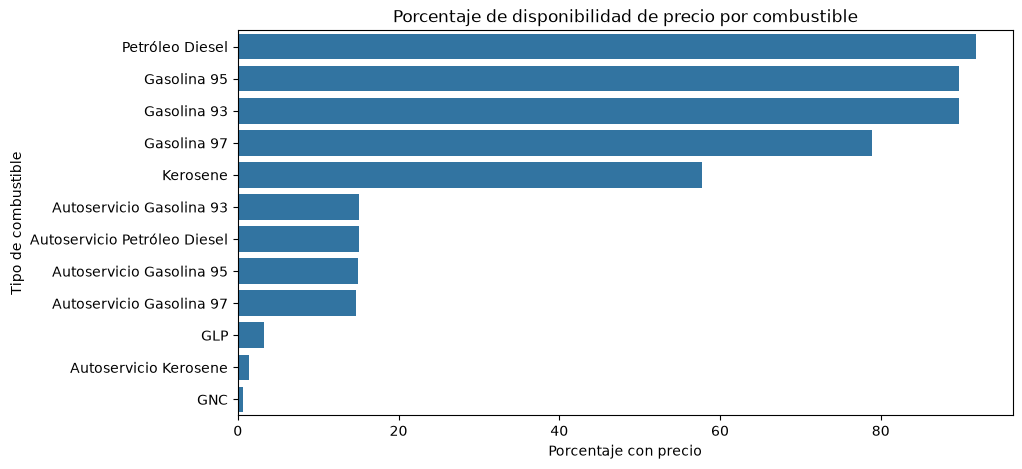

In [145]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=disponibilidad_combustible,
    y="nombre_combustible",
    x="porcentaje_con_precio"
)
plt.title("Porcentaje de disponibilidad de precio por combustible")
plt.xlabel("Porcentaje con precio")
plt.ylabel("Tipo de combustible")
plt.show()

## 16. Criterios de limpieza

A partir de la revisión anterior, se aplican los siguientes criterios:

1. Se consolida el archivo original para dejar una sola fila por estación.
2. La columna `horario_atencion` no se incluye en el dataset limpio principal, porque presenta alta cantidad de valores faltantes y genera repeticiones por estación.
3. Se mantienen todos los tipos de combustible que tengan precio válido.
4. Se eliminan únicamente combinaciones estación-combustible sin precio.
5. No se eliminan combustibles completos por baja disponibilidad.
6. Los combustibles con mayor disponibilidad se usarán como foco del análisis principal.
7. Los pocos nulos en latitud y longitud se conservan, ya que afectan principalmente al mapa, pero no impiden análisis por comuna, región o distribuidor.
8. Las columnas finales se seleccionan para mantener un dataset limpio, interpretable y útil para el dashboard.

## 17. Eliminación de filas sin precio

Se eliminan las filas donde `precio` es nulo o menor/igual a cero.

Estas filas representan combinaciones estación-combustible sin información útil para análisis de precios.

In [146]:
filas_antes = len(df_limpio)

df_limpio = df_limpio.dropna(subset=["precio"])
df_limpio = df_limpio[df_limpio["precio"] > 0]

filas_despues = len(df_limpio)

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues)
print("Porcentaje eliminado:", round((filas_antes - filas_despues) / filas_antes * 100, 2), "%")

Filas antes: 21768
Filas después: 8580
Filas eliminadas: 13188
Porcentaje eliminado: 60.58 %


## 18. Validaciones posteriores a la limpieza

Se verifica que no queden precios nulos ni precios inválidos.

In [147]:
assert df_limpio["precio"].isna().sum() == 0, "Aún existen precios nulos"
assert (df_limpio["precio"] > 0).all(), "Existen precios menores o iguales a cero"

print("Validación correcta: no hay precios nulos ni precios menores o iguales a cero.")

Validación correcta: no hay precios nulos ni precios menores o iguales a cero.


In [148]:
nulos_despues = pd.DataFrame({
    "nulos": df_limpio.isna().sum(),
    "porcentaje": df_limpio.isna().mean() * 100,
}).sort_values("porcentaje", ascending=False)

nulos_despues

,nulos,porcentaje
longitud,8,0.09324
latitud,4,0.04662
distribuidor,0,0.00000
en_mantenimiento,0,0.00000
codigo_estacion,0,0.00000
razon_social,0,0.00000
codigo_region,0,0.00000
region,0,0.00000
provincia,0,0.00000
codigo_provincia,0,0.00000


## 19. Revisión de registros finales por combustible

Se revisa cuántos registros válidos quedan por tipo de combustible después de la limpieza.

In [149]:
registros_finales_combustible = (
    df_limpio
    .groupby(
        ["tipo_combustible", "nombre_combustible", "combustible_base", "modalidad"],
        as_index=False
    )
    .agg(
        cantidad_registros=("precio", "count"),
        cantidad_estaciones=("codigo_estacion", "nunique"),
        precio_promedio=("precio", "mean"),
        precio_minimo=("precio", "min"),
        precio_maximo=("precio", "max"),
    )
    .sort_values("cantidad_registros", ascending=False)
)

registros_finales_combustible

,tipo_combustible,nombre_combustible,combustible_base,modalidad,cantidad_registros,cantidad_estaciones,precio_promedio,precio_minimo,precio_maximo
8,DI,Petróleo Diesel,Petróleo Diesel,Atención normal,1666,1666,1368.902761,317.0,13860.0
1,95,Gasolina 95,Gasolina 95,Atención normal,1628,1628,1567.382064,1170.0,15950.0
0,93,Gasolina 93,Gasolina 93,Atención normal,1627,1627,1529.693915,1124.0,15700.0
2,97,Gasolina 97,Gasolina 97,Atención normal,1431,1431,1627.662474,1230.0,16270.0
11,KE,Kerosene,Kerosene,Atención normal,1048,1048,1083.728053,990.0,1593.0
3,A93,Autoservicio Gasolina 93,Gasolina 93,Autoservicio,274,274,1488.952555,1386.0,1819.0
6,ADI,Autoservicio Petróleo Diesel,Petróleo Diesel,Autoservicio,273,273,1332.304029,1229.0,1633.0
4,A95,Autoservicio Gasolina 95,Gasolina 95,Autoservicio,271,271,1527.302583,1428.0,1715.0
5,A97,Autoservicio Gasolina 97,Gasolina 97,Autoservicio,267,267,1571.074906,1277.0,1748.0
9,GLP,GLP,GLP,Atención normal,59,59,651.474576,469.0,857.0


## 20. Revisión de duplicados

Como el dataset está en formato largo, una misma estación puede aparecer varias veces si vende distintos combustibles. Por lo tanto, repetir `codigo_estacion` no es un problema.

Lo que sí se revisa es:

- Duplicados exactos: filas completamente idénticas.
- Duplicados por clave estación-combustible: más de una fila para la misma estación y el mismo tipo de combustible.

Si los duplicados por estación-combustible también son duplicados exactos, se pueden eliminar sin perder información.

In [156]:
duplicados_exactos = df_limpio.duplicated().sum()

duplicados_clave = df_limpio.duplicated(
    subset=["codigo_estacion", "tipo_combustible"]
).sum()

print("Duplicados exactos en dataset limpio:", duplicados_exactos)
print("Duplicados por estación y combustible:", duplicados_clave)

Duplicados exactos en dataset limpio: 0
Duplicados por estación y combustible: 0


In [157]:
assert duplicados_exactos == 0, "Existen duplicados exactos en dataset limpio"
assert duplicados_clave == 0, "Existen duplicados por estación y combustible"

print("Validación correcta: no hay duplicados en el dataset limpio.")

Validación correcta: no hay duplicados en el dataset limpio.


## 21. Selección y orden de columnas finales

El archivo original incluye muchas columnas adicionales, como servicios, medios de pago y logos.

Para esta versión del análisis se priorizan columnas necesarias para:

- identificar la estación;
- ubicarla geográficamente;
- analizar combustible y modalidad;
- comparar precios;
- saber fecha/hora de actualización;
- conocer si está en mantenimiento.

Las columnas de servicios y métodos de pago se mantienen en el archivo original, pero no se incluyen en `dataset_limpio.csv` para conservar un dataset simple y orientado al objetivo del proyecto.

In [153]:
columnas_finales = [
    # Identificación de estación
    "codigo_estacion",
    "razon_social",
    "distribuidor",

    # Ubicación geográfica: de mayor a menor escala
    "region",
    "codigo_region",
    "provincia",
    "codigo_provincia",
    "comuna",
    "codigo_comuna",
    "direccion",
    "latitud",
    "longitud",

    # Combustible
    "tipo_combustible",
    "nombre_combustible",
    "combustible_base",
    "modalidad",

    # Precio y actualización
    "precio",
    "fecha_actualizacion",
    "hora_actualizacion",
    "unidad_cobro",
    "tipo_atencion",

    # Estado de estación
    "en_mantenimiento",
]

# Validar que todas las columnas finales existan
columnas_faltantes = [
    col for col in columnas_finales
    if col not in df_limpio.columns
]

if columnas_faltantes:
    raise ValueError(f"Faltan columnas en df_limpio: {columnas_faltantes}")

df_limpio = df_limpio[columnas_finales]

df_limpio.head()

,codigo_estacion,razon_social,distribuidor,region,codigo_region,provincia,codigo_provincia,comuna,codigo_comuna,direccion,latitud,longitud,tipo_combustible,nombre_combustible,combustible_base,modalidad,precio,fecha_actualizacion,hora_actualizacion,unidad_cobro,tipo_atencion,en_mantenimiento
1,co1410106,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,AV. DIEGO PORTALES 1072,-18.474145,-70.303257,93,Gasolina 93,Gasolina 93,Atención normal,1580.0,2026-06-18,08:26:11,$/L,Asistido,0
2,co1510101,rach gasoil limitada,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,SAN MARTÍN 699,-18.479848,-70.313417,93,Gasolina 93,Gasolina 93,Atención normal,1576.0,2026-06-18,10:58:34,$/L,Asistido,0
3,co1510102,VICTOR HUGO CORTES BRAVO Y CIA. LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,PANAMERICANA SUR 2824,-18.493503,-70.289095,93,Gasolina 93,Gasolina 93,Atención normal,1580.0,2026-06-18,09:53:12,$/L,Asistido,0
4,co1510103,SOC. REYES TAMAYO LIMITADA 76.012.325-0,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,LUIS VALENTE ROSSI 1990,-18.490415,-70.302297,93,Gasolina 93,Gasolina 93,Atención normal,1568.0,2026-06-17,23:57:50,$/L,Asistido,0
5,co1510104,ESTACIONES DE SERVICIO SEGUEL Y CIA . LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,18 DE SEPTIEMBRE 2401,-18.489835,-70.290275,93,Gasolina 93,Gasolina 93,Atención normal,1580.0,2026-06-18,07:11:56,$/L,Asistido,0


## 22. Resumen final de limpieza

Se genera un resumen con las dimensiones y categorías principales del dataset limpio.

In [158]:
resumen_limpieza = {
    "filas_dataset_crudo_estaciones": df_estaciones.shape[0],
    "columnas_dataset_crudo_estaciones": df_estaciones.shape[1],
    "filas_dataset_original_base": df_estaciones_base.shape[0],
    "columnas_dataset_original_base": df_estaciones_base.shape[1],
    "filas_formato_largo": df_largo.shape[0],
    "filas_dataset_limpio": df_limpio.shape[0],
    "columnas_dataset_limpio": df_limpio.shape[1],
    "estaciones_unicas": df_limpio["codigo_estacion"].nunique(),
    "regiones": df_limpio["region"].nunique(),
    "provincias": df_limpio["provincia"].nunique(),
    "comunas": df_limpio["comuna"].nunique(),
    "distribuidores": df_limpio["distribuidor"].nunique(),
    "combustibles_base": df_limpio["combustible_base"].nunique(),
    "tipos_combustible": df_limpio["tipo_combustible"].nunique(),
}

resumen_limpieza

{'filas_dataset_crudo_estaciones': 2039,
 'columnas_dataset_crudo_estaciones': 96,
 'filas_dataset_original_base': 1814,
 'columnas_dataset_original_base': 95,
 'filas_formato_largo': 21768,
 'filas_dataset_limpio': 8580,
 'columnas_dataset_limpio': 22,
 'estaciones_unicas': 1793,
 'regiones': 16,
 'provincias': 55,
 'comunas': 312,
 'distribuidores': 122,
 'combustibles_base': 7,
 'tipos_combustible': 12}

## 23. Guardar dataset limpio

Finalmente, se guarda el dataset limpio en `data/dataset_limpio.csv`.

In [155]:
df_limpio.to_csv(
    dataset_limpio_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset limpio guardado en:", dataset_limpio_path)
print("Filas:", df_limpio.shape[0])
print("Columnas:", df_limpio.shape[1])

df_limpio.head()

Dataset limpio guardado en: ..\data\dataset_limpio.csv
Filas: 8580
Columnas: 22


,codigo_estacion,razon_social,distribuidor,region,codigo_region,provincia,codigo_provincia,comuna,codigo_comuna,direccion,latitud,longitud,tipo_combustible,nombre_combustible,combustible_base,modalidad,precio,fecha_actualizacion,hora_actualizacion,unidad_cobro,tipo_atencion,en_mantenimiento
1,co1410106,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,AV. DIEGO PORTALES 1072,-18.474145,-70.303257,93,Gasolina 93,Gasolina 93,Atención normal,1580.0,2026-06-18,08:26:11,$/L,Asistido,0
2,co1510101,rach gasoil limitada,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,SAN MARTÍN 699,-18.479848,-70.313417,93,Gasolina 93,Gasolina 93,Atención normal,1576.0,2026-06-18,10:58:34,$/L,Asistido,0
3,co1510102,VICTOR HUGO CORTES BRAVO Y CIA. LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,PANAMERICANA SUR 2824,-18.493503,-70.289095,93,Gasolina 93,Gasolina 93,Atención normal,1580.0,2026-06-18,09:53:12,$/L,Asistido,0
4,co1510103,SOC. REYES TAMAYO LIMITADA 76.012.325-0,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,LUIS VALENTE ROSSI 1990,-18.490415,-70.302297,93,Gasolina 93,Gasolina 93,Atención normal,1568.0,2026-06-17,23:57:50,$/L,Asistido,0
5,co1510104,ESTACIONES DE SERVICIO SEGUEL Y CIA . LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,18 DE SEPTIEMBRE 2401,-18.489835,-70.290275,93,Gasolina 93,Gasolina 93,Atención normal,1580.0,2026-06-18,07:11:56,$/L,Asistido,0


## 24. Conclusión de limpieza

El dataset original fue consolidado para dejar una sola fila por estación. Algunas estaciones aparecían repetidas debido a distintos bloques en `horario_atencion`; sin embargo, esta columna presenta una alta proporción de valores faltantes y no se utiliza en esta primera versión del dataset limpio.

Luego, el dataset fue transformado desde formato ancho a formato largo, permitiendo que cada fila represente una combinación entre estación de servicio y tipo de combustible.

La limpieza no eliminó combustibles completos. Se eliminaron únicamente las combinaciones sin precio, ya que no permiten realizar comparaciones ni calcular rankings. Además, se conservaron registros con coordenadas faltantes, porque estos siguen siendo útiles para análisis por comuna, región y distribuidor.

También se enriqueció el dataset con provincia utilizando el Código Único Territorial, manteniendo la información geográfica ordenada desde región hasta coordenadas.

El archivo `dataset_limpio.csv` queda preparado para el análisis exploratorio y para el desarrollo del dashboard.